# Calculo de Eigenvalores para un modelo de BTC (Boundary Time Crystals) https://arxiv.org/abs/1708.05014
 Importamos librerias importantes, principalmente qutip que ya nos hace la vectorización para el Liouvilliano y para definir los operadores e incluso para realizar los productos tensoriales de manera sencilla

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

vec1= basis(5,2) 
up = basis(2,0) # (1,0)
down = basis(2,1) # (0,1)

upx = (basis(2,0) + basis(2,1)).unit() # Initial state “The system is initialised in the pure state with all spins aligned along the x-direction…”

Probando como hacer matrices de densidad y trazas parciales usando las funciones de qutip

In [3]:
# Matriz de densidad para 2 espines

psi = (1/np.sqrt(2))*(1/np.sqrt(2))*(tensor(up,down) - tensor(down,up)) 

rho = psi * psi.dag()

rho_0 = rho.ptrace(0) # Tr_1 rho
rho_1 = rho.ptrace(1)

## Queremos obtener los eigenvalores del Liouvilliano
En general y en la función de qutip 

$$\mathcal{L}[\rho] = i[\rho, H] + \left( L\rho L^{\dagger} - \frac{1}{2} \{L^{\dagger}L, \rho\} \right) = \lambda \rho$$

En el modelo usan el siguiente Hamiltoniano

$$H = \omega_0 \sum_j \sigma^x_j$$
En el paper usan la siguiente expresión ya simplificada

$$\mathcal{L}[\rho] = i\omega_0[\rho, S^x] + \frac{\kappa}{S}\left( S_{-}\rho S_{+} - \frac{1}{2} \{S_{+}S_{-}, \rho\} \right)$$


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

def build_system(Nb): # Nb: Spin en la frontera
    S = Nb/2 # Spin total
    k = 1
    w_0 = 1.5*k 
    
# Defining spin operators
    Sx = jmat(S, 'x')
    Sy = jmat(S, 'y')
    Sz = jmat(S, 'z')
    S2 = Sx**2 + Sy**2 + Sz**2
    Sm = np.sqrt(k/S)*jmat(S, '-')

# Hamiltonian
    H = w_0*Sx

    jump_ops = [Sm]
    expected_ops = [S2,Sx,Sy,Sz]
    
    return H, jump_ops, expected_ops, S
    
def do_spectrum(Nb):
    H, jump_ops, _, _ = build_system(Nb)

    L = liouvillian(H, jump_ops)
    eigs = L.eigenenergies()

    return eigs

def simulation(Nb):

    H, jump_ops, exp_ops, S = build_system(Nb)
#  All spins up in z i.e |S, M=S>, for ini state
    psi_z = basis(int(2*S+1), 0)

#  Rotando pi/2
#  U = (-1j * np.pi/2 * Sy).expm()
#  psi_x = U * psi_z
    psi_x = spin_coherent(S, np.pi/2, 0)
    rho0x = psi_x * psi_x.dag()
    rho0z = psi_z * psi_z.dag()

    t = np.linspace(0, 60, 200)
    
    evo = mesolve(H, rho0x, t, jump_ops, exp_ops)
    #evo2 = mesolve(H, rho0z, t, jump_ops, expected_ops)
    return evo


results = {}
eigenvalues = {}

In [14]:

for Nb in [20,40,80,120,160,200]:
    eigenvalues[Nb] = do_spectrum(Nb)

In [ ]:
for Nb in [20,40,80,120]:
    results[Nb] = simulation(Nb)

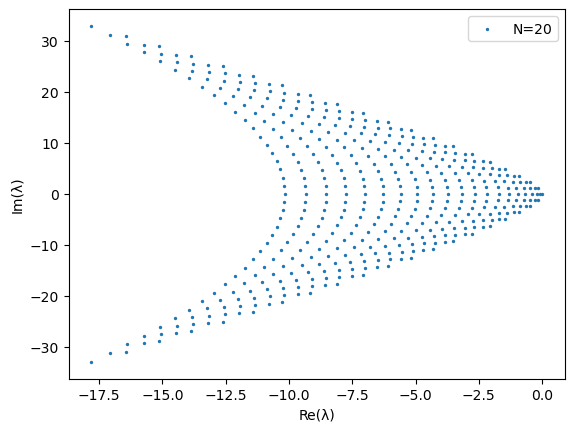

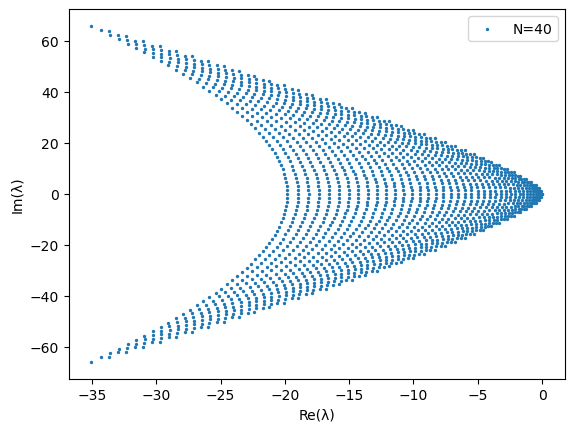

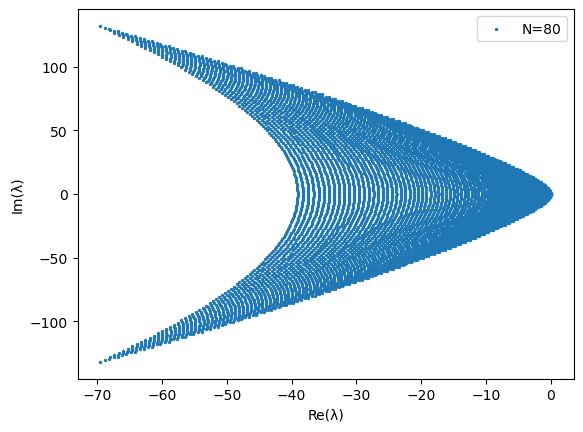

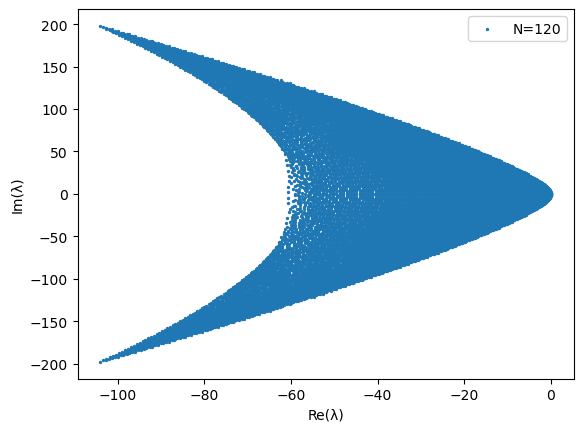

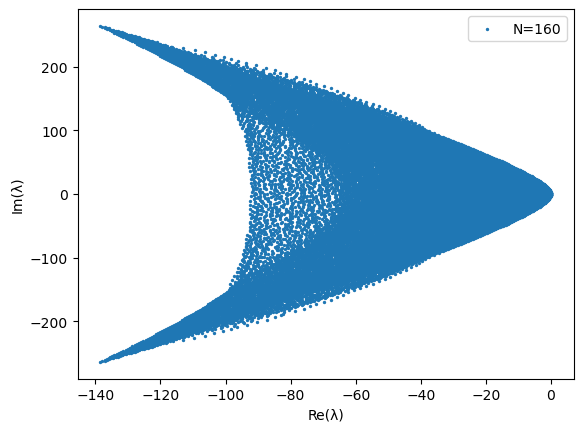

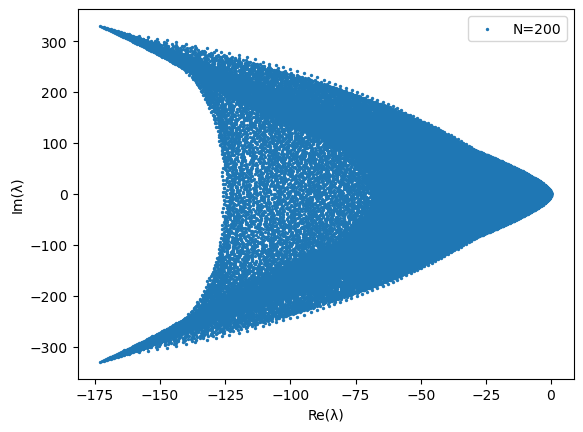

In [25]:

k=1
for Nb, eigs in eigenvalues.items():
    plt.scatter(np.real(eigs)/k, np.imag(eigs)/k, label=f'N={Nb}', s=2)
    plt.xlabel("Re(λ)")
    plt.ylabel("Im(λ)")
    plt.legend()
    plt.show()

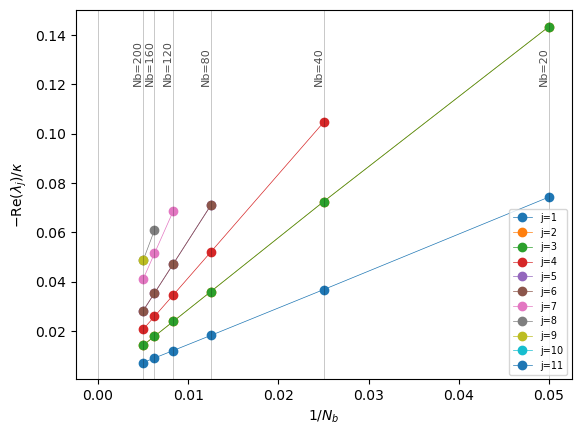

In [63]:
real_scaling = {}

eps = 0.5

for Nb, eigs in eigenvalues.items():

    # Ordenarlos de mayor a menor, 
    # La funcion argsort devuelve un array con las posiciones de menor a mayor entonces lo invertimos con [::-1]
    eigs_sorted = eigs[np.argsort(np.real(eigs))[::-1]]

    selected = []

    # Aquí sec considera el criterio que hace el paper j^2/Nb < epsilon, en este codigo eps = 0.5
    for j, eig in enumerate(eigs_sorted):

        nu = j**2 / Nb

        if nu < eps:
            selected.append((j, np.real(eig)/k))

    real_scaling[Nb] = selected

max_j = 12

for j in range(1, max_j):

    x = []
    y = []

    for Nb in sorted(real_scaling.keys()):    # Este loop corre por 20,40,80,...,200

        data = real_scaling[Nb]

        if j < len(data):

            x.append(1/Nb)
            y.append(-data[j][1]) # -Re(lambda)
    plt.plot(x, y, 'o-', label=f'j={j}', lw=0.5)
plt.xlabel(r'$1/N_b$')
plt.ylabel(r'$-\mathrm{Re}(\lambda_j)/\kappa$')
plt.axvline(0, lw=0.5, c='black', alpha=0.3)

for Nb in sorted(real_scaling.keys()):
    plt.axvline(1/Nb, lw=0.5, c='black', alpha=0.3)
    ymin, ymax = plt.ylim()

    plt.text(
        1/Nb,
        ymax*0.8,
        f'Nb={Nb}',
        rotation=90,
        fontsize=8,
        ha='right',
        alpha=0.7
    )
plt.legend(fontsize='x-small', loc = 'lower right')
plt.show()

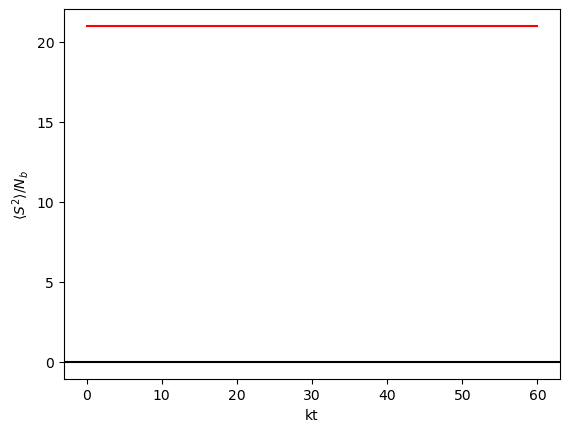

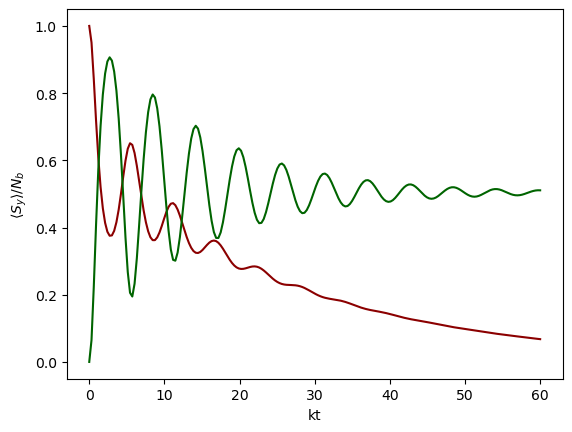

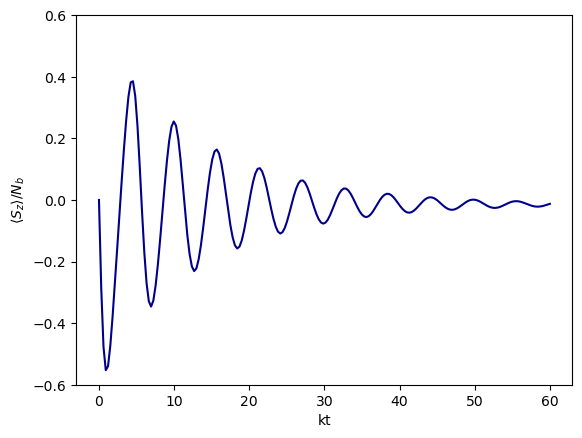

In [44]:

# rho0 = all spin up in x
'''
Graficas de los otros operadores

plt.plot( k*t, evo1.expect[0]/S, c='red')
plt.xlabel("kt")
plt.ylabel(r"$\langle S^2\rangle / N_b$")
plt.axhline(0, c='black')
plt.show()

plt.plot( k*t, evo1.expect[1]/S, c='darkred')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_x\rangle / N_b$")


plt.plot( k*t, evo1.expect[2]/S, c='darkgreen')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_y\rangle / N_b$")
plt.show()
'''

plt.plot( k*t, evo1.expect[3]/S, c='darkblue')
plt.xlabel("kt")
plt.ylabel(r"$\langle S_z\rangle / N_b$")
plt.ylim(-0.6,0.6)
#plt.savefig("dyn100z.png")
plt.show()



